In [2]:
!pip install -q kagglehub imageio

import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import PIL
import imageio.v2 as imageio
import tensorflow as tf
from tensorflow.keras import layers
from IPython import display
import kagglehub

In [16]:
import os

base_train_path = "/kaggle/input/gtsrb-german-traffic-sign/Train"

print("Exists:", os.path.exists(base_train_path))
print("First 20 class folders:")
print(sorted(os.listdir(base_train_path))[:20])

Exists: True
First 20 class folders:
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26']


In [20]:
import os
import glob
import random

base_train_path = "/kaggle/input/gtsrb-german-traffic-sign/Train"

selected_classes = ["1", "2", "3", "4", "5"]

image_paths = []
for cls in selected_classes:
    class_dir = os.path.join(base_train_path, cls)
    print("Checking:", class_dir, "->", os.path.exists(class_dir))
    class_paths = glob.glob(os.path.join(class_dir, "*.png"))
    print("Found", len(class_paths), "images in class", cls)
    image_paths.extend(class_paths)

print("Images before shuffle:", len(image_paths))

random.shuffle(image_paths)
image_paths = image_paths[:4000]

print("Images used:", len(image_paths))
if image_paths:
    print("Type of first item:", type(image_paths[0]))


Checking: /kaggle/input/gtsrb-german-traffic-sign/Train/1 -> True
Found 2220 images in class 1
Checking: /kaggle/input/gtsrb-german-traffic-sign/Train/2 -> True
Found 2250 images in class 2
Checking: /kaggle/input/gtsrb-german-traffic-sign/Train/3 -> True
Found 1410 images in class 3
Checking: /kaggle/input/gtsrb-german-traffic-sign/Train/4 -> True
Found 1980 images in class 4
Checking: /kaggle/input/gtsrb-german-traffic-sign/Train/5 -> True
Found 1860 images in class 5
Images before shuffle: 9720
Images used: 4000
Type of first item: <class 'str'>


In [21]:
IMG_SIZE = 28
BATCH_SIZE = 64
BUFFER_SIZE = len(image_paths)

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image
train_dataset = (
    tf.data.Dataset.from_tensor_slices(image_paths)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

Batch shape: (64, 28, 28, 1)
Min: -0.9428855 Max: 0.99980015


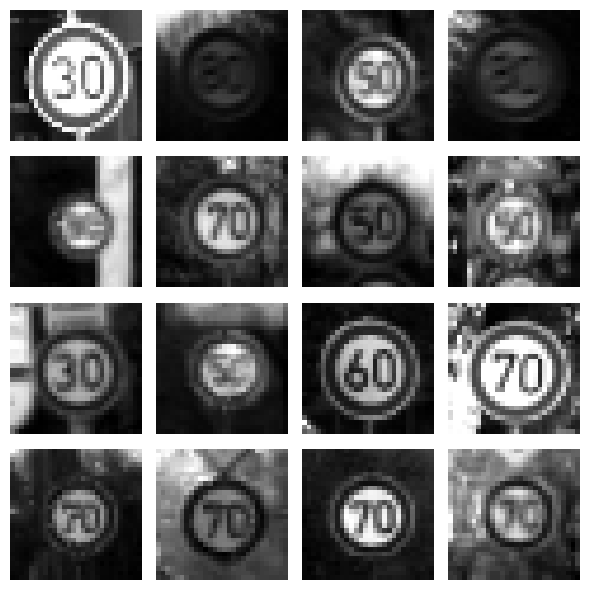

In [22]:
for batch in train_dataset.take(1):
    print("Batch shape:", batch.shape)
    print("Min:", tf.reduce_min(batch).numpy(), "Max:", tf.reduce_max(batch).numpy())

    sample = (batch[:16] + 1.0) / 2.0
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(sample[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [24]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generate_and_save_images(model, epoch, test_input, prefix):
    predictions = model(test_input, training=False)

    plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{prefix}_epoch_{epoch:03d}.png")
    plt.show()

def make_gif(prefix, output_name):
    filenames = sorted(glob.glob(f"{prefix}_epoch_*.png"))
    with imageio.get_writer(output_name, mode='I') as writer:
        for filename in filenames:
            writer.append_data(imageio.imread(filename))
        writer.append_data(imageio.imread(filenames[-1]))
    print("Saved:", output_name)

Part A — DCGAN

In [26]:
def make_dcgan_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(7 * 7 * 512, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 512)),

        layers.Conv2DTranspose(256, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

def make_dcgan_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

In [27]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, noise_dim])

dcgan_generator = make_dcgan_generator()
dcgan_discriminator = make_dcgan_discriminator()

dcgan_gen_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
dcgan_disc_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

DCGAN Epoch 50, Time: 3.68s


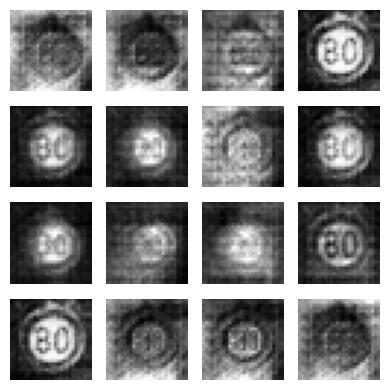

In [28]:
@tf.function
def dcgan_train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = dcgan_generator(noise, training=True)

        real_output = dcgan_discriminator(images, training=True)
        fake_output = dcgan_discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, dcgan_generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, dcgan_discriminator.trainable_variables)

    dcgan_gen_optimizer.apply_gradients(zip(gradients_of_generator, dcgan_generator.trainable_variables))
    dcgan_disc_optimizer.apply_gradients(zip(gradients_of_discriminator, dcgan_discriminator.trainable_variables))

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    for image_batch in train_dataset:
        dcgan_train_step(image_batch)

    display.clear_output(wait=True)
    print(f"DCGAN Epoch {epoch}, Time: {time.time() - start:.2f}s")
    generate_and_save_images(dcgan_generator, epoch, seed, "dcgan")

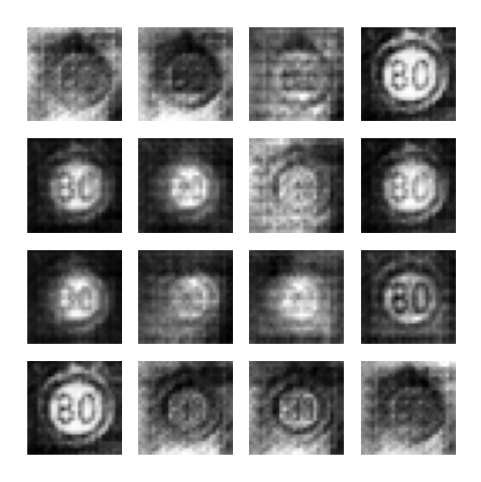

Saved: dcgan_gtsrb.gif


In [29]:
plt.figure(figsize=(6, 6))
plt.imshow(PIL.Image.open(f"dcgan_epoch_{EPOCHS:03d}.png"))
plt.axis("off")
plt.show()
make_gif("dcgan", "dcgan_gtsrb.gif")

Part B — MLP GAN

In [31]:
def make_mlp_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),

        layers.Dense(256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Dense(512, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Dense(1024, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Dense(28 * 28 * 1, activation='tanh'),
        layers.Reshape((28, 28, 1))
    ])
    return model

def make_mlp_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(512),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Dense(1)
    ])
    return model

In [32]:
mlp_generator = make_mlp_generator()
mlp_discriminator = make_mlp_discriminator()

mlp_gen_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
mlp_disc_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def mlp_train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = mlp_generator(noise, training=True)

        real_output = mlp_discriminator(images, training=True)
        fake_output = mlp_discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, mlp_generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, mlp_discriminator.trainable_variables)

    mlp_gen_optimizer.apply_gradients(zip(gradients_of_generator, mlp_generator.trainable_variables))
    mlp_disc_optimizer.apply_gradients(zip(gradients_of_discriminator, mlp_discriminator.trainable_variables))

MLP GAN Epoch 50, Time: 1.70s


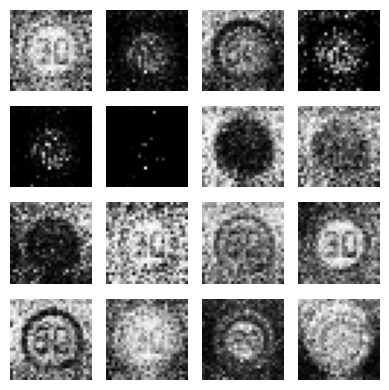

In [33]:
for epoch in range(1, EPOCHS + 1):
    start = time.time()

    for image_batch in train_dataset:
        mlp_train_step(image_batch)

    display.clear_output(wait=True)
    print(f"MLP GAN Epoch {epoch}, Time: {time.time() - start:.2f}s")
    generate_and_save_images(mlp_generator, epoch, seed, "mlpgan")

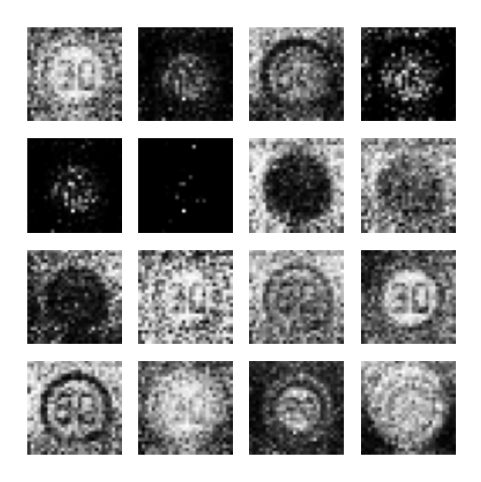

Saved: mlpgan_gtsrb.gif


In [34]:
plt.figure(figsize=(6, 6))
plt.imshow(PIL.Image.open(f"mlpgan_epoch_{EPOCHS:03d}.png"))
plt.axis("off")
plt.show()

make_gif("mlpgan", "mlpgan_gtsrb.gif")

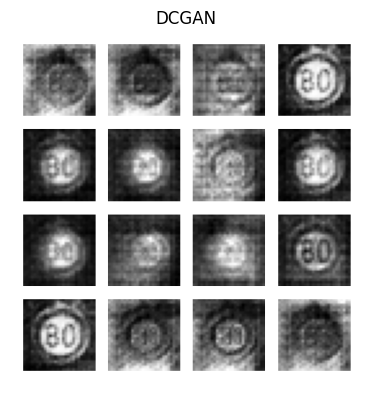

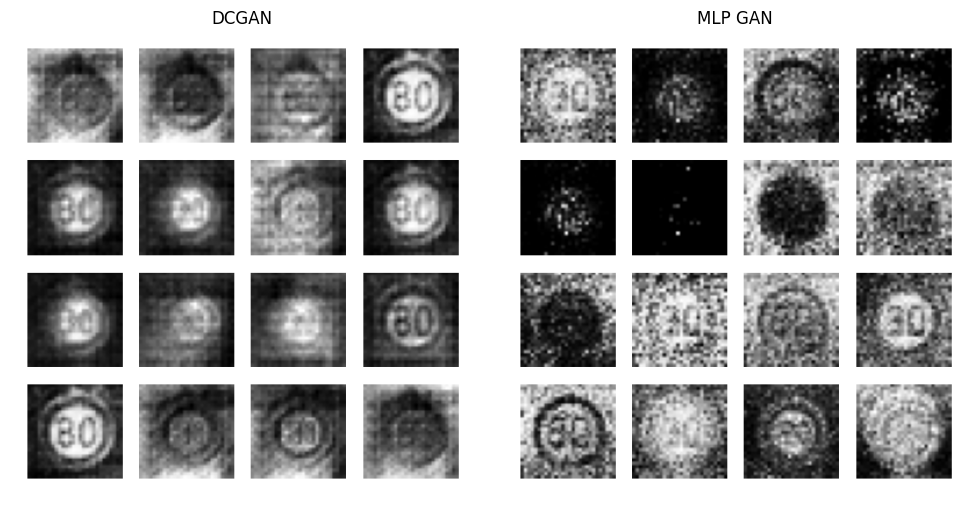

In [35]:
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(PIL.Image.open(f"dcgan_epoch_{EPOCHS:03d}.png"))
ax1.set_title("DCGAN")
ax1.axis("off")

fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(PIL.Image.open(f"dcgan_epoch_{EPOCHS:03d}.png"))
ax1.set_title("DCGAN")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(PIL.Image.open(f"mlpgan_epoch_{EPOCHS:03d}.png"))
ax2.set_title("MLP GAN")
ax2.axis("off")

plt.tight_layout()
plt.show()